# Block 2 Project: CO₂ capture with PSA/VSA

Group C

Team members: Pamela Sampaa Afaki, Sarhini Nour, Chiara Nicole Bifulco, Alice Bolard

We compare the assigned MOFs for CO₂ capture from a gas containing 15% CO₂ and 85% N₂. Adsorption takes place at 1 bar and 25 °C, followed by desorption at 0.2 bar. 

We are studying the following MOFs: UTSA-80, UTSA-20, NOTT-300, Mg-MOF-74 and ZIF-8. The exports report 298 K, which we use as the simulation temperature (approximately 25 °C).

In [2]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyiast
from IPython.display import display

DATA = Path("data/block2_project")
T = 298.0  # actual temperature reported in the simulation exports
P_ADS, P_DES = 1.0, 0.2  # bar
y = np.array([0.15, 0.85])  # order: CO₂, N₂


def read_export(filename):
    return pd.read_csv(DATA / filename, index_col="Key")["Value"]


ModuleNotFoundError: No module named 'pyiast'

## 1. Pore analysis

Pore analysis describes the space available for adsorption. All five datasets use a probe radius of 1.525 Å. Density is the mass per crystal volume, ASA is the surface area accessible to the probe and POAV is the accessible volume that the probe can occupy. Porosity is POAV divided by the unit cell volume.

Results for question 1:

| Material | Density (g·cm⁻³) | ASA (Å² per unit cell) | POAV (Å³ per unit cell) | Porosity |
|:---|---:|---:|---:|---:|
| UTSA-80 | 0.678 | 3115 | 9620 | 0.668 |
| NOTT-300 | 1.039 | 453.5 | 1297 | 0.490 |
| ZIF-8 | 0.910 | 787.4 | 2488 | 0.499 |
| Mg-MOF-74 | 0.886 | 222.8 | 837.2 | 0.614 |
| UTSA-20 | 0.882 | 1308 | 3575 | 0.629 |

UTSA-80 has the largest accessible pore fraction of these materials (about 67%). Surface areas and pore volumes per unit cell depend on cell size, so values per gram are more useful for comparing materials. Geometry alone does not establish CO₂ affinity or separation performance.

In [2]:
pore_files = {
    "UTSA-80": "UTSA-80_pore_analysis.csv",
    "NOTT-300": "NOTT-300_pore_analysis.csv",
    "ZIF-8": "ZIF-8_pore_analysis.csv",
    "Mg-MOF-74": "Mg-MOF_pore_analysis.csv",
    "UTSA-20": "UTSA-20_pore_screenshot.csv",
}
rows = []
for material, filename in pore_files.items():
    pore = read_export(filename)
    if "Input_volpo" in pore:
        probe_radius = ast.literal_eval(pore["Input_volpo"])[0]
    else:
        probe_radius = float(pore["Probe_radius"])
    assert np.isclose(probe_radius, 1.525), f"Check probe radius for {material}"
    porosity = float(pore["POAV_Volume_fraction"])
    if "Unitcell_volume" in pore:
        phi_check = float(pore["POAV_A^3"]) / float(pore["Unitcell_volume"])
        assert np.isclose(phi_check, porosity, atol=1e-4)
    rows.append({
        "Material": material,
        "Density (g·cm⁻³)": float(pore["Density"]),
        "ASA (Å²/cell)": float(pore["ASA_A^2"]),
        "POAV (Å³/cell)": float(pore["POAV_A^3"]),
        "Porosity": porosity,
        "ASA (m²·g⁻¹)": float(pore.get("ASA_m^2/g", np.nan)),
        "POAV (cm³·g⁻¹)": float(pore.get("POAV_cm^3/g", np.nan)),
    })
pore_results = pd.DataFrame(rows).set_index("Material")
display(pore_results.round(3).fillna("Not supplied"))

,Density (g·cm⁻³),ASA (Å²/cell),POAV (Å³/cell),Porosity,ASA (m²·g⁻¹),POAV (cm³·g⁻¹)
Material,,,,,,
UTSA-80,0.678,3114.620,9619.780,0.668,3188.86,0.985
NOTT-300,1.039,453.452,1297.110,0.490,1648.23,0.471
ZIF-8,0.910,787.421,2488.250,0.499,1736.33,0.549
Mg-MOF-74,0.886,222.828,837.198,0.614,1842.96,0.692
UTSA-20,0.882,1307.510,3575.360,0.629,Not supplied,Not supplied


## 2. Henry coefficients and CO₂ affinity

At very low pressure, adsorption follows Henry's law, $q=K_H P$. A larger CO₂ Henry coefficient indicates greater CO₂ uptake at the same sufficiently low pressure. We rank the materials by decreasing CO₂ Henry coefficient.

In [3]:
gas_files = {
    "UTSA-80": {"CO2": "utsa8-co2.csv", "N2": "utsa80-n2.csv"},
    "UTSA-20": {"CO2": "utsa20-co2.csv", "N2": "utsa20-n2.csv"},
    "NOTT-300": {"CO2": "nott300-co2.csv", "N2": "nott300-n2.csv"},
    "Mg-MOF-74": {"CO2": "mgmof-co2.csv", "N2": "mgmof-n2.csv"},
    "ZIF-8": {"CO2": "zif-co2.csv", "N2": "zif-n2.csv"},
}
exports, isotherms, henry_rows = {}, {}, []
for material, files in gas_files.items():
    row = {"Material": material}
    for gas, filename in files.items():
        result = read_export("received_isotherms/" + filename)
        exports[material, gas] = result
        if "temperature" in result:
            assert np.isclose(float(result["temperature"]), T)
        row[f"KH {gas} (mol·kg⁻¹·Pa⁻¹)"] = float(result.get("henry_coefficient_average", np.nan))
        row[f"KH deviation {gas}"] = float(result.get("henry_coefficient_dev", np.nan))
        if "isotherm" in result:
            d = ast.literal_eval(result["isotherm"])
            assert d["pressure_unit"] == "bar"
            assert d["loading_absolute_unit"] == "mol/kg"
            frame = pd.DataFrame({"P": d["pressure"], "q": d["loading_absolute_average"],
                                  "error": d["loading_absolute_dev"]}).sort_values("P")
            assert np.isfinite(frame.to_numpy()).all() and (frame[["P", "q", "error"]] >= 0).all().all()
            assert not frame.P.duplicated().any()
            isotherms[material, gas] = frame
    row["Henry selectivity"] = row["KH CO2 (mol·kg⁻¹·Pa⁻¹)"] / row["KH N2 (mol·kg⁻¹·Pa⁻¹)"]
    henry_rows.append(row)
henry = pd.DataFrame(henry_rows).set_index("Material").sort_values("KH CO2 (mol·kg⁻¹·Pa⁻¹)", ascending=False)
display(henry)


,KH CO2 (mol·kg⁻¹·Pa⁻¹),KH deviation CO2,KH N2 (mol·kg⁻¹·Pa⁻¹),KH deviation N2,Henry selectivity
Material,,,,,
NOTT-300,0.000184,4.952490e-07,0.000011,2.465900e-08,17.494943
Mg-MOF-74,0.000086,3.014030e-06,0.000003,1.532620e-08,25.799866
UTSA-20,0.000041,2.245780e-07,0.000004,1.685390e-08,9.328610
UTSA-80,0.000017,9.367960e-08,0.000003,4.453100e-09,5.114832
ZIF-8,0.000009,2.548330e-08,NaN,NaN,NaN


Results for question 2:

| Material | CO₂ Henry coefficient (mol·kg⁻¹·Pa⁻¹) | N₂ Henry coefficient (mol·kg⁻¹·Pa⁻¹) | Henry-coefficient ratio |
|:---|---:|---:|---:|
| NOTT-300 | 1.842 × 10⁻⁴ | 1.053 × 10⁻⁵ | 17.49 |
| Mg-MOF-74 | 8.578 × 10⁻⁵ | 3.325 × 10⁻⁶ | 25.80 |
| UTSA-20 | 4.091 × 10⁻⁵ | 4.385 × 10⁻⁶ | 9.33 |
| UTSA-80 | 1.705 × 10⁻⁵ | 3.333 × 10⁻⁶ | 5.11 |
| ZIF-8 | 8.821 × 10⁻⁶ | Not calculated | Not available |

The CO₂ affinity ranking is: NOTT-300 > Mg-MOF-74 > UTSA-20 > UTSA-80 > ZIF-8. Affinity alone does not give the separation ranking: Mg-MOF-74 has a larger Henry-coefficient ratio than NOTT-300 because its N₂ affinity is lower.

### ZIF-8 and N₂ accessibility

The N₂ export reports `is_porous = False`, zero accessible volume and zero estimated saturation loading for the workflow's 1.655 Å probe. The workflow therefore skipped Widom and GCMC; no N₂ Henry coefficient or isotherm was calculated. The pore-limiting diameter is about 3.39 Å, consistent with restricted access in the rigid structure. These are geometric screening results, not measured zero N₂ uptake. The workflow did not calculate N₂ adsorption because the rigid-structure accessibility check found no accessible pore volume. This does not establish zero N₂ uptake in the real material, where framework flexibility can allow access ([N₂ framework-flexibility study](https://doi.org/10.1016/j.micromeso.2013.12.012)).

## 3. Pure-component isotherms

The GCMC isotherms show adsorption from 0.2 to 10.2 bar at 298 K. Each gas is plotted separately, with all available materials on the same axes. Error bars show the loading deviations reported by the simulations.

The requested settings were 500 initialisation cycles, 5,000 production cycles, 50,000 Widom cycles, 10,000 Zeo++ volume samples and 100 blocking samples, with a maximum pressure spacing of 0.6 bar.

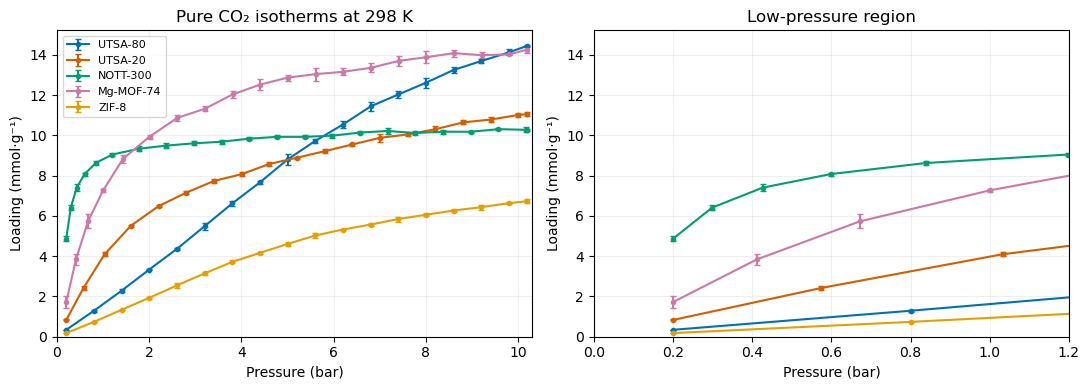

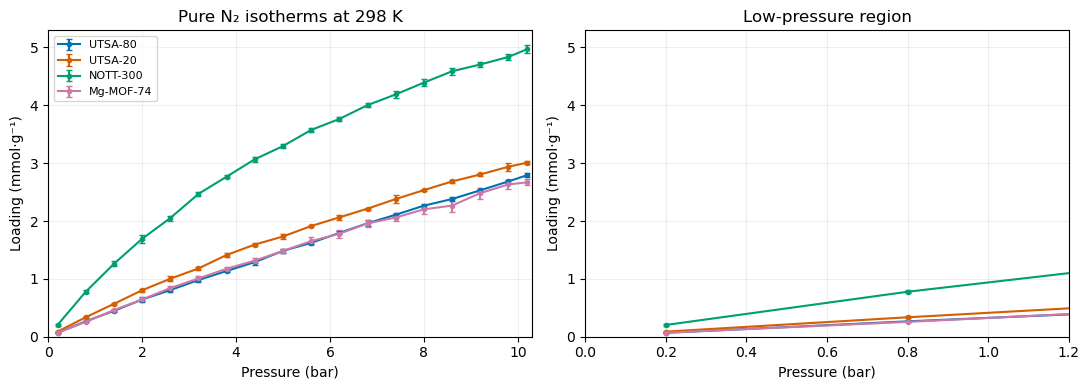

In [4]:
colours = dict(zip(gas_files, ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]))
for gas, label in [("CO2", "CO₂"), ("N2", "N₂")]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for material in gas_files:
        if (material, gas) not in isotherms:
            continue
        df = isotherms[material, gas]
        for ax in axes:
            ax.errorbar(df.P, df.q, yerr=df.error, fmt="o-", ms=3, capsize=2,
                        color=colours[material], label=material)
    for ax, limit in zip(axes, [10.3, 1.2]):
        ax.set_xlim(0, limit)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Pressure (bar)")
        ax.set_ylabel("Loading (mmol·g⁻¹)")
        ax.grid(alpha=0.2)
    axes[0].set_title(f"Pure {label} isotherms at {T:.0f} K")
    axes[1].set_title("Low-pressure region")
    axes[0].legend(fontsize=8)
    fig.tight_layout()
    plt.show()


From the graphs, we can see that NOTT-300 has the greatest pure CO₂ uptake at the first simulated pressure, 0.2 bar (4.87 mmol·g⁻¹). At 10.2 bar, UTSA-80 and Mg-MOF-74 reach about 14.45 and 14.26 mmol·g⁻¹, respectively, exceeding NOTT-300 which reached a plateau at around 10.26 mmol·g⁻¹. This shows that the uptake ranking depends on pressure. For this process, mixture behaviour near the adsorption and desorption conditions matters more than the largest uptake at 10.2 bar. No N₂ curve is drawn for ZIF-8 because it was not simulated, as explained above.

## 4. CO₂ working capacity

The working capacity is the difference between binary CO₂ loadings at adsorption and desorption:

$$WC=q_{CO_2,\mathrm{ads}}-q_{CO_2,\mathrm{des}}.$$

We use IAST with linear interpolation of the pure-gas data at 1 and 0.2 bar, assuming 15% CO₂ and 85% N₂ at both pressures. This gives an equilibrium screening estimate, rather than a full cycle prediction. The interpolator connects the origin to the first simulated point at 0.2 bar. We do not extrapolate above the highest available pressure.

In [5]:
complete = [m for m in gas_files if all((m, g) in isotherms for g in ["CO2", "N2"])]
models = {(m, g): pyiast.InterpolatorIsotherm(isotherms[m, g], pressure_key="P", loading_key="q")
          for m in complete for g in ["CO2", "N2"]}


def mixture_loading(material, pressure):
    objects = [models[material, gas] for gas in ["CO2", "N2"]]
    q = np.asarray(pyiast.iast(pressure * y, objects))
    assert np.isfinite(q).all() and (q > 0).all()
    x = q / q.sum()
    reference_pressures = pressure * y / x
    for gas, p0 in zip(["CO2", "N2"], reference_pressures):
        assert p0 <= isotherms[material, gas].P.max(), "More pure-gas data are required"
    spreading = [obj.spreading_pressure(p0) for obj, p0 in zip(objects, reference_pressures)]
    assert np.isclose(*spreading, rtol=1e-6, atol=1e-8)
    return q, reference_pressures


mixture_rows, reference_rows = [], []
for material in complete:
    qa, pa = mixture_loading(material, P_ADS)
    qd, pd0 = mixture_loading(material, P_DES)
    mixture_rows.append({"Material": material, "CO₂ ads (mmol·g⁻¹)": qa[0],
        "CO₂ des (mmol·g⁻¹)": qd[0], "N₂ ads (mmol·g⁻¹)": qa[1],
        "WC (mmol·g⁻¹)": qa[0] - qd[0], "Selectivity": qa[0] / qa[1] * y[1] / y[0]})
    for state, p0 in [("Adsorption", pa), ("Desorption", pd0)]:
        reference_rows.append({"Material": material, "State": state,
                              "CO₂ reference P (bar)": p0[0], "N₂ reference P (bar)": p0[1]})
mixture = pd.DataFrame(mixture_rows).set_index("Material")
references = pd.DataFrame(reference_rows)
assert (mixture["WC (mmol·g⁻¹)"] > 0).all()
display(mixture[["CO₂ ads (mmol·g⁻¹)", "CO₂ des (mmol·g⁻¹)", "WC (mmol·g⁻¹)"]].round(3))
display(references.round(3))


,CO₂ ads (mmol·g⁻¹),CO₂ des (mmol·g⁻¹),WC (mmol·g⁻¹)
Material,,,
UTSA-80,0.250,0.051,0.198
UTSA-20,0.614,0.124,0.490
NOTT-300,3.512,0.726,2.786
Mg-MOF-74,1.277,0.258,1.020


,Material,State,CO₂ reference P (bar),N₂ reference P (bar)
0,UTSA-80,Adsorption,0.314,1.629
1,UTSA-80,Desorption,0.063,0.323
2,UTSA-20,Adsorption,0.234,2.365
3,UTSA-20,Desorption,0.048,0.458
4,NOTT-300,Adsorption,0.178,5.354
5,NOTT-300,Desorption,0.037,0.909
6,Mg-MOF-74,Adsorption,0.181,4.915
7,Mg-MOF-74,Desorption,0.037,0.953


Results for question 4:

| Material | CO₂ at 1 bar (mmol·g⁻¹) | CO₂ at 0.2 bar (mmol·g⁻¹) | Working capacity (mmol·g⁻¹) |
|:---|---:|---:|---:|
| NOTT-300 | 3.512 | 0.726 | 2.786 |
| Mg-MOF-74 | 1.277 | 0.258 | 1.020 |
| UTSA-20 | 0.614 | 0.124 | 0.490 |
| UTSA-80 | 0.250 | 0.051 | 0.198 |

The ranking based on CO₂ working capacity is therefore:

${\text{NOTT-300} > \text{Mg-MOF-74} > \text{UTSA-20} > \text{UTSA-80}}
$

NOTT-300 has the highest working capacity under the screening assumptions, meaning that it can theoretically release the largest amount of CO₂ during the pressure swing among the materials studied.

For each material, the CO₂ loading at desorption is about 20% of that at adsorption, so working capacity is approximately 80% of the adsorption loading. Indeed, the low-pressure IAST predictions rely partly on linear interpolation below the first GCMC point, so the Henry coefficients can be used as an additional consistency check.

## 5. CO₂/N₂ selectivity

We calculate selectivity from binary IAST loadings at the adsorption conditions (1 bar, 298 K, 15% CO₂):

$$S_{CO_2/N_2}=\frac{q_{CO_2}}{q_{N_2}}\frac{y_{N_2}}{y_{CO_2}}.$$

A value greater than 1 indicates preferential CO₂ adsorption.

In [7]:
display(mixture[["CO₂ ads (mmol·g⁻¹)", "N₂ ads (mmol·g⁻¹)", "Selectivity"]]
        .sort_values("Selectivity", ascending=False).round(3))

,CO₂ ads (mmol·g⁻¹),N₂ ads (mmol·g⁻¹),Selectivity
Material,,,
NOTT-300,3.512,0.663,30.025
Mg-MOF-74,1.277,0.267,27.100
UTSA-20,0.614,0.345,10.098
UTSA-80,0.250,0.272,5.192


All four materials have a selectivity greater than 1, meaning that they preferentially adsorb CO₂ over N₂.

The ranking based on selectivity is:

${\text{NOTT-300} > \text{Mg-MOF-74} > \text{UTSA-20} > \text{UTSA-80}}$

NOTT-300 and Mg-MOF-74 show the strongest preference for CO₂ while UTSA-20 and especially UTSA-80 show a weaker preference. This suggests that the first two materials are more promising for CO₂/N₂ separation based on selectivity alone.

## 6. Ranking using working capacity and selectivity

We plot working capacity against selectivity. Materials towards the upper-right corner combine greater recoverable CO₂ uptake with stronger preference for CO₂. A material dominates another when it is at least as good on both measures and strictly better on at least one.

In [1]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for material, row in mixture.iterrows():
    wc = row["WC (mmol·g⁻¹)"]
    selectivity = row["Selectivity"]

    ax.scatter(wc, selectivity, s=70, color=colours[material])
    ax.annotate(
        material,
        (wc, selectivity),
        xytext=(7, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel("CO₂ working capacity (mmol·g⁻¹)")
ax.set_ylabel("CO₂/N₂ selectivity at 1 bar")
ax.set_title("MOF ranking: working capacity vs selectivity")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

ranking = mixture.sort_values("WC (mmol·g⁻¹)", ascending=False)
display(ranking[["WC (mmol·g⁻¹)", "Selectivity"]].round(3))

NameError: name 'plt' is not defined

The plot compares the MOFs using their CO₂ working capacity and CO₂/N₂ selectivity. A higher working capacity means that more CO₂ can be released per gram during the pressure cycle, while a higher selectivity indicates a stronger preference for CO₂ over N₂. Materials with high values of both are therefore favourable for this screening.

The results give the following ranking: $NOTT-300 > Mg-MOF-74 > UTSA-20 > UTSA-80$. NOTT-300 has the highest working capacity, approximately 2.79 mmol/g, and the highest selectivity, approximately 30.0. Whereas, Mg-MOF-74 has a similar selectivity of 27.1, but a lower working capacity of 1.02 mmol/g. UTSA-20 and UTSA-80 have lower values for both criteria.

NOTT-300 is therefore the most promising candidate among the four materials under the conditions studied. ZIF-8 cannot be included in this ranking because its N₂ isotherm is unavailable.


## 7. Is this screening sufficient?
Our screening suggests that NOTT-300 is the most promising material under the conditions studied, because it has the highest predicted CO₂ working capacity and CO₂/N₂ selectivity. However, this does not establish which material would perform best in a real PSA/VSA process.

The screening first considered the geometry of the materials: using density, accessible surface area and pore volume in Question 1. Question 2 then examined their affinity for the gases: using Henry coefficients and adsorption energies. Finally, Questions 3 to 6 investigated adsorption equilibrium: using pure-gas isotherms and IAST to predict mixture loadings, working capacity and selectivity. Our final ranking therefore corresponds to an equilibrium-level screening.

A more advanced screening would use a simplified process model with mass and energy balances over an adsorption cycle. A detailed process model would additionally account for adsorption rates, heat transfer, pressure changes and the optimisation of cycle conditions. Neither of these process models was included in this project.

Our calculations compare adsorption at 1 bar and desorption at 0.2 bar, both at the feed composition and 298 K. In an actual cycle, the gas composition changes during desorption, and adsorption and desorption can change the temperature of the bed. The time needed to capture and release CO₂ also affects performance. These effects, together with the energy required to generate a vacuum and compress the recovered CO₂, are not captured by our ranking.

The molecular simulations also introduce limitations. The frameworks were treated as rigid, which can restrict access to pores that may become accessible when the real structure moves. This is relevant to ZIF-8, for which the N₂ calculation was excluded by the pore-accessibility check. The predicted adsorption also depends on the force field, particularly for materials with specific binding sites such as the open metal sites in Mg-MOF-74. In addition, the low-pressure mixture predictions depend on the interpolation of the available isotherm data. Finally, real flue gas contains water and other components that can compete for adsorption or affect the stability of the material.

Several additional key performance indicators would improve the comparison. From our existing results, we can calculate the fraction of adsorbed CO₂ released during depressurisation, by dividing the working capacity by the CO₂ loading at adsorption. This indicates how much of the captured CO₂ is available for release in the chosen pressure swing. We can also estimate a crystal-based volumetric working capacity by multiplying the gravimetric working capacity by the crystal density. This compares the materials per unit crystal volume, although a practical comparison would require the packed-bed density.

At the process level, CO₂ purity measures the proportion of CO₂ in the recovered product, while CO₂ recovery measures the fraction of incoming CO₂ that is collected. Productivity describes the amount recovered per unit adsorbent mass or bed volume per unit time, so it accounts for cycle duration as well as capacity. Specific energy consumption measures the energy required per unit mass of CO₂ recovered. These indicators would need a process model and should be compared under the same purity and recovery requirements.

NOTT-300 therefore leads our equilibrium screening, but the final choice would require evaluating these process indicators and the materials’ stability under realistic operating conditions.

### More complex key performance indicators

Some additional indicators can already be calculated from our data:

In [9]:
kpi = mixture[["WC (mmol·g⁻¹)", "Selectivity"]].copy()
kpi["Regenerability (%)"] = 100 * mixture["WC (mmol·g⁻¹)"] / mixture["CO₂ ads (mmol·g⁻¹)"]
kpi["Volumetric WC (mmol·cm⁻³)"] = mixture["WC (mmol·g⁻¹)"] * pore_results.loc[mixture.index, "Density (g·cm⁻³)"]
kpi["CO₂ adsorption energy (kJ·mol⁻¹)"] = [float(exports[m, "CO2"]["adsorption_energy_widom_average"])
                                          for m in mixture.index]
display(kpi.round(2))


,WC (mmol·g⁻¹),Selectivity,Regenerability (%),Volumetric WC (mmol·cm⁻³),CO₂ adsorption energy (kJ·mol⁻¹)
Material,,,,,
UTSA-80,0.20,5.19,79.43,0.13,-16.39
UTSA-20,0.49,10.10,79.79,0.43,-19.90
NOTT-300,2.79,30.02,79.34,2.90,-23.63
Mg-MOF-74,1.02,27.10,79.83,0.90,-24.38


To compare the materials more completely, we would need indicators beyond working capacity and selectivity.

Two additional indicators can be estimated from our existing results. The fraction of CO₂ released is the working capacity divided by the CO₂ loading at the adsorption pressure. It tells us what proportion of the captured CO₂ is released during depressurisation. The volumetric working capacity measures the amount released per unit volume rather than per gram. This matters because an industrial adsorption column has a limited volume. Multiplying our working capacity by the crystal density gives an initial estimate, although a practical assessment would require the packed-bed density.

Other indicators require a model of the complete adsorption cycle. CO₂ purity describes how much of the recovered gas is CO₂ rather than N₂. CO₂ recovery describes how much of the incoming CO₂ is successfully collected. Both matter: a process could produce a very pure CO₂ stream while collecting only a small fraction of the CO₂ entering the column.

Productivity measures how much CO₂ is recovered per unit of adsorbent mass or bed volume per unit time. It accounts for the speed of the process, which working capacity alone does not describe. Specific energy consumption measures the energy required per unit mass of CO₂ recovered, including the energy needed to generate a vacuum and compress the product.

These indicators would help identify a material that captures and releases enough CO₂, produces a sufficiently pure product, operates quickly and uses little energy. They could therefore lead to a different ranking from the one obtained using only equilibrium working capacity and selectivity.

## Summary

Our equilibrium screening identifies NOTT-300 as the most promising material for CO₂/N₂ separation, with a CO₂ working capacity of 2.79 mmol/g and a selectivity of 30.0. It is followed by Mg-MOF-74, UTSA-20 and UTSA-80. ZIF-8 could not be ranked because its N₂ isotherm was unavailable.

These results provide an initial shortlist rather than a final choice for a PSA/VSA process. Further evaluation of CO₂ purity, recovery, productivity, energy consumption and material stability is needed to determine which material performs best in practice.

## References

- Project assignment sheet.
- [pyIAST documentation](https://pyiast.readthedocs.io/en/stable/).
- [AiiDA-LSMO isotherm workflow](https://aiida-lsmo.readthedocs.io/en/latest/_modules/aiida_lsmo/workchains/isotherm.html).
- [N₂ in ZIF-8: sorbate-induced structural changes and self-diffusion (2014)](https://doi.org/10.1016/j.micromeso.2013.12.012).